## DSC640, Term Project Milestone 5
### Childcare Cost Analysis in the United States
### Teresa Ferrill, May 31, 2026

The term project is a review of the National Database of Childcare Prices.   
>Dataset: National Database of Childcare Prices    
>Source: U.S. Department of Labor – Women's Bureau   

Milestone 5 is the finalized version of the term project 
>All data and/or visual elements have been polished and are ready for final submission

-----------------------------------------------------------------------------------------------------------------
### Childcare Costs and Affordability in the United States
This analysis explores how childcare costs vary across states, age groups, and care types using the National Database of Childcare Prices.

### Dataset Overview
The dataset includes childcare costs by state and is broken down by:  

- MC = Center-based childcare    
- MFCC = Family childcare (home-based care)    
- Infant, Toddler, Preschool = age groups    

All values represent weekly childcare costs.

### Focus of Analysis
This analysis focuses on differences in childcare costs across states, age groups, and care types, with particular attention to affordability and variation across regions.

### Target Audience
The target audience includes policymakers, working parents, and organizational leaders interested in understanding childcare affordability and its impact on workforce participation.

### Direction of Story
The goal is to highlight how childcare costs vary significantly across states and care types, and how these differences may impact financial stability and workforce participation.

### Communication Mediums  
1. Dashboard - interactive view of childcare costs and affordability depending on where families live  
2. Slide Presentation – a structured, insight-driven narrative highlighting key cost trends, regional differences, and affordability challenges    
3. Infographic – a simplified, high-level summary of childcare cost disparities, designed for broader communication and awareness

Summary provides a solid foundation for understanding childcare challenges such as workforce participation and economic stability.   

### Summary of Design Decisions  
1. Visual choices intentionally limited to bar and line charts to support precise comparisons across states, age groups, and care types
2. Layout and spacing were structured to guide the audience from high-level trends to more detailed insights
3. Each medium builds on the same core findings while serving a distinct purpose

### Assumptions  
- Childcare cost data represents average weekly costs per state.  
- Missing values were excluded from analysis.  
- Costs are comparable across states without adjusting for cost of living.  

### Summary of Analysis
This analysis explored childcare costs across states using multiple dimensions, including age group, care type, and geographic region. Visualizations were used to identify patterns and highlight cost variability.  

-----------------------------------------------------------------------------------------------------------------
This notebook performs initial exploratory analysis of childcare costs in the United States to identify patterns and potential insights for data storytelling.  

Step 1: Initializes libraries, loads the dataset, and prepares it for analysis, with backup loading options included.

In [1]:
# Step 1 - 
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import openpyxl

# Set plot defaults
plt.rcParams["figure.figsize"] = (12,7)
sns.set_style("whitegrid")

# Import dataset
file = "data/nationaldatabaseofchildcareprices.zip"

df = pd.read_csv(
    file,
    compression="zip",
    low_memory=False
)

df.head()

,State_Name,State_Abbreviation,County_Name,County_FIPS_Code,StudyYear,UNR_16,FUNR_16,MUNR_16,UNR_20to64,FUNR_20to64,...,MFCCToddler,MFCCToddler_flag,MFCCPreschool,MFCCPreschool_flag,_75FCCInfant,_75FCCInfant_flag,_75FCCToddler,_75FCCToddler_flag,_75FCCPreschool,_75FCCPreschool_flag
0,Alabama,AL,Autauga County,1001,2008,5.4,4.4,6.3,4.6,3.5,...,$83.45,3.0,$81.40,1.0,$97.40,1.0,$97.40,3.0,$95.00,1.0
1,Alabama,AL,Autauga County,1001,2009,5.9,5.7,6.1,4.8,4.6,...,$87.39,3.0,$85.68,1.0,$102.00,1.0,$102.00,3.0,$100.00,1.0
2,Alabama,AL,Autauga County,1001,2010,6.2,5.6,6.8,5.1,4.6,...,$91.33,3.0,$89.96,1.0,$106.60,1.0,$106.60,3.0,$105.00,1.0
3,Alabama,AL,Autauga County,1001,2011,7.6,8.1,7.0,6.2,6.3,...,$95.28,3.0,$94.25,1.0,$111.20,1.0,$111.20,3.0,$110.00,1.0
4,Alabama,AL,Autauga County,1001,2012,8.6,8.9,8.3,6.7,6.4,...,$99.22,3.0,$98.53,1.0,$115.80,1.0,$115.80,3.0,$115.00,1.0


This block of code prepares the environment and ensures the dataset is properly loaded and ready for subsequent data cleaning, exploration, and visualization.  The first rows of the data set are reviewed.  

-----------------------------------------------------------------------------------------------------------------
Step 2: Checking for missing data  

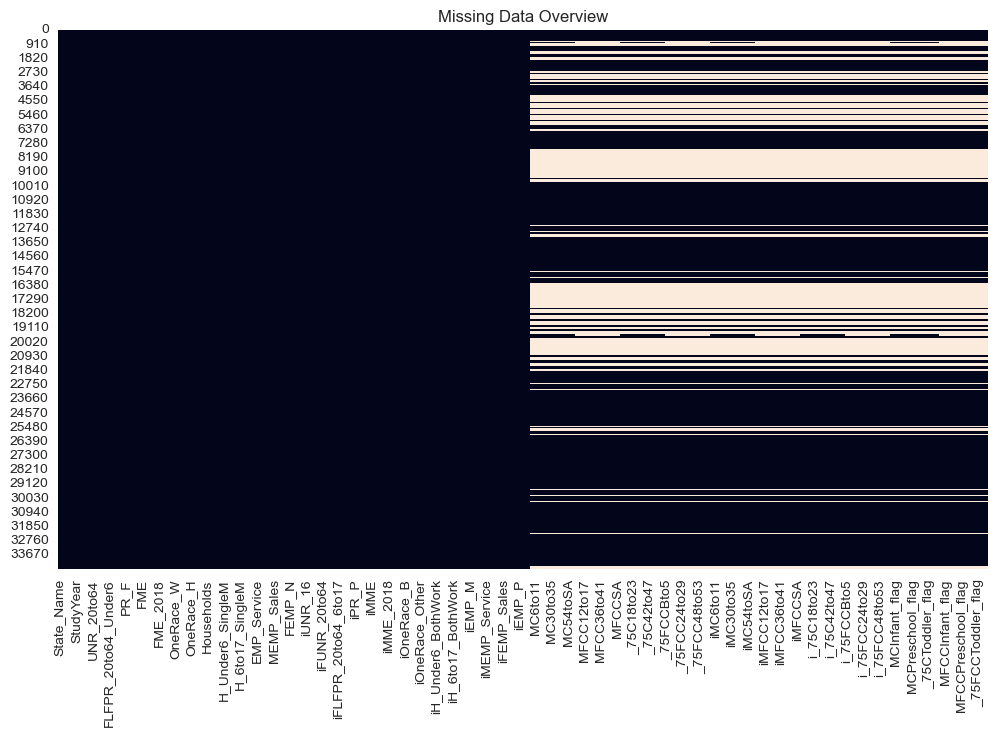

In [2]:
# Step 2
# Check missing data
df.isnull().sum()
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Overview")
plt.show()

The dataset was reviewed for missing values using both summary counts and a heatmap. Missing values were handled by excluding them from the cost calculations where needed.

-----------------------------------------------------------------------------------------------------------------
Step 3: List of all column names

In [3]:
# Step 3
# List all column names
list(df.columns)

['State_Name',
 'State_Abbreviation',
 'County_Name',
 'County_FIPS_Code',
 'StudyYear',
 'UNR_16',
 'FUNR_16',
 'MUNR_16',
 'UNR_20to64',
 'FUNR_20to64',
 'MUNR_20to64',
 'FLFPR_20to64',
 'FLFPR_20to64_Under6',
 'FLFPR_20to64_6to17',
 'FLFPR_20to64_Under6_6to17',
 'MLFPR_20to64',
 'PR_F',
 'PR_P',
 'MHI',
 'ME',
 'FME',
 'MME',
 'MHI_2018',
 'ME_2018',
 'FME_2018',
 'MME_2018',
 'TotalPop',
 'OneRace',
 'OneRace_W',
 'OneRace_B',
 'OneRace_I',
 'OneRace_A',
 'OneRace_H',
 'OneRace_Other',
 'TwoRaces',
 'Hispanic',
 'Households',
 'H_Under6_BothWork',
 'H_Under6_FWork',
 'H_Under6_MWork',
 'H_Under6_SingleM',
 'H_6to17_BothWork',
 'H_6to17_Fwork',
 'H_6to17_Mwork',
 'H_6to17_SingleM',
 'EMP_M',
 'MEMP_M',
 'FEMP_M',
 'EMP_Service',
 'MEMP_Service',
 'FEMP_Service',
 'EMP_Sales',
 'MEMP_Sales',
 'FEMP_Sales',
 'EMP_N',
 'MEMP_N',
 'FEMP_N',
 'EMP_P',
 'MEMP_P',
 'FEMP_P',
 'iUNR_16',
 'iFUNR_16',
 'iMUNR_16',
 'iUNR_20to64',
 'iFUNR_20to64',
 'iMUNR_20to64',
 'iFLFPR_20to64',
 'iFLFPR_2

The column names of the dataset were listed.

-----------------------------------------------------------------------------------------------------------------
Step 4: Distribution of Center-Based Childcare Prices  
Combine center-based childcare prices across infant, toddler, and preschool categories into a single dataset, removes missing values, and calculates the overall mean and median - creating a histogram to show the distribution of weekly childcare costs, with vertical lines added to highlight the average and midpoint values.  

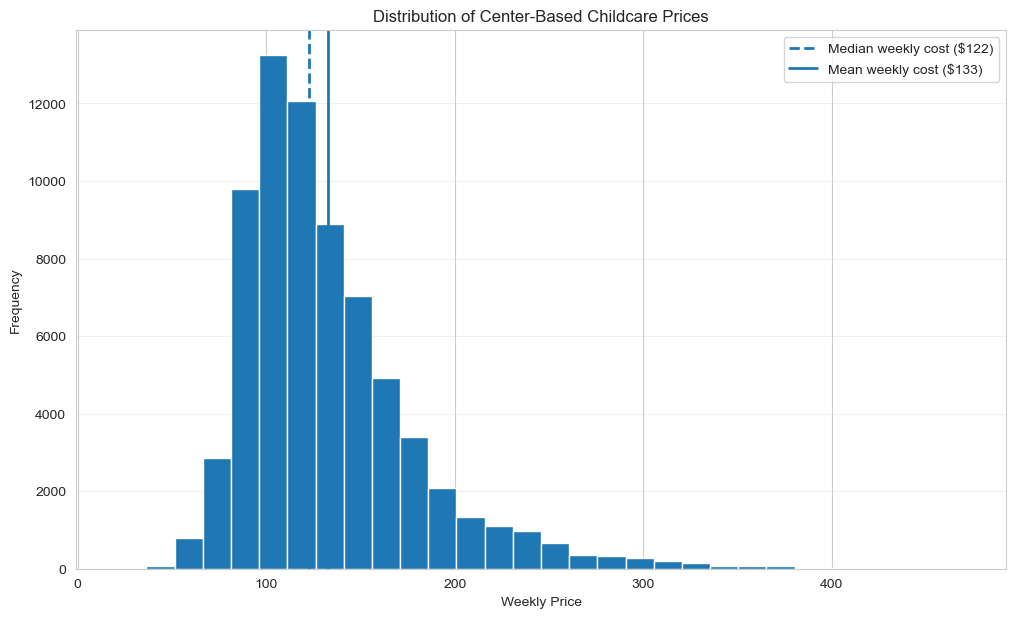

In [4]:
# Step 4
# Basic cost distribution using center-based care prices
price_data_centerBased = pd.concat([
    df["MCInfant"],
    df["MCToddler"],
    df["MCPreschool"]
], axis=0).dropna()

# Calculate statistics
median_price = price_data_centerBased.median()
mean_price = price_data_centerBased.mean()

# Plot histogram
plt.figure(figsize=(12,7))
plt.hist(price_data_centerBased, bins=30)

# Add median line
plt.axvline(median_price,
            linestyle='--',
            linewidth=2,
            label=f'Median weekly cost (${median_price:.0f})')

# Add mean line
plt.axvline(mean_price,
            linestyle='-',
            linewidth=2,
            label=f'Mean weekly cost (${mean_price:.0f})')

# Titles and labels
plt.title("Distribution of Center-Based Childcare Prices")
plt.xlabel("Weekly Price")
plt.ylabel("Frequency")

# Optional grid for readability
plt.grid(axis='y', alpha=0.3)

# Legend
plt.legend()

plt.show()

The histogram shows that center-based childcare costs are spread across a wide range, with most prices clustering in the mid-range. The mean appears slightly higher than the median, suggesting a right-skewed distribution driven by higher-cost outliers.

-----------------------------------------------------------------------------------------------------------------
Step 5: Distribution of Family Daycare Childcare Prices  
Combines family daycare childcare prices across infant, toddler, and preschool categories into a single dataset, removes missing values, and calculates the mean and median - Creating a histogram to visualize the distribution of weekly prices, with vertical lines marking the average and midpoint values.

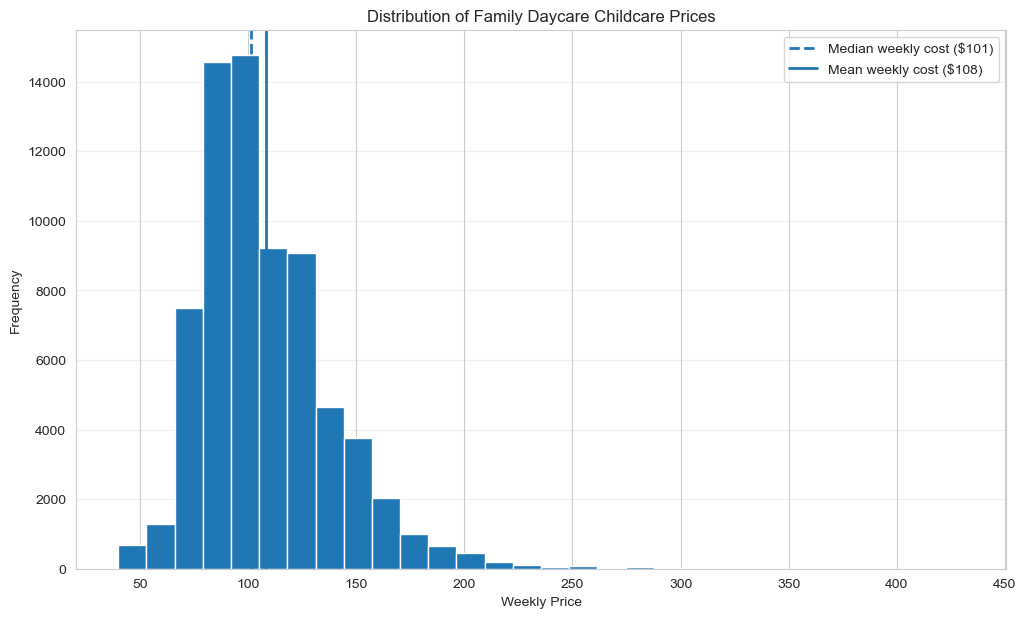

In [5]:
# Step 5
# Basic cost distribution using family daycare prices
price_data_familyDaycare = pd.concat([
    df["MFCCInfant"],
    df["MFCCToddler"],
    df["MFCCPreschool"]
], axis=0).dropna()

# Calculate statistics
median_price = price_data_familyDaycare.median()
mean_price = price_data_familyDaycare.mean()

# Plot histogram
plt.figure(figsize=(12,7))
plt.hist(price_data_familyDaycare, bins=30)

# Add median line
plt.axvline(median_price,
            linestyle='--',
            linewidth=2,
            label=f'Median weekly cost (${median_price:.0f})')

# Add mean line
plt.axvline(mean_price,
            linestyle='-',
            linewidth=2,
            label=f'Mean weekly cost (${mean_price:.0f})')

# Titles and labels
plt.title("Distribution of Family Daycare Childcare Prices")
plt.xlabel("Weekly Price")
plt.ylabel("Frequency")

# Optional grid
plt.grid(axis='y', alpha=0.3)

# Legend
plt.legend()

plt.show()

The histogram shows that family daycare costs are generally lower and more tightly clustered than center-based care, with a slight right skew indicating some higher-cost outliers.

-----------------------------------------------------------------------------------------------------------------
Step 6: Average Cost by State - Family Daycare 
This code calculates the average family daycare childcare cost for each state by grouping the data and averaging prices across infant, toddler, and preschool categories - computing an overall average cost per state, sorts the states from highest to lowest, and highlights the top five most expensive states using a different color in a bar chart.

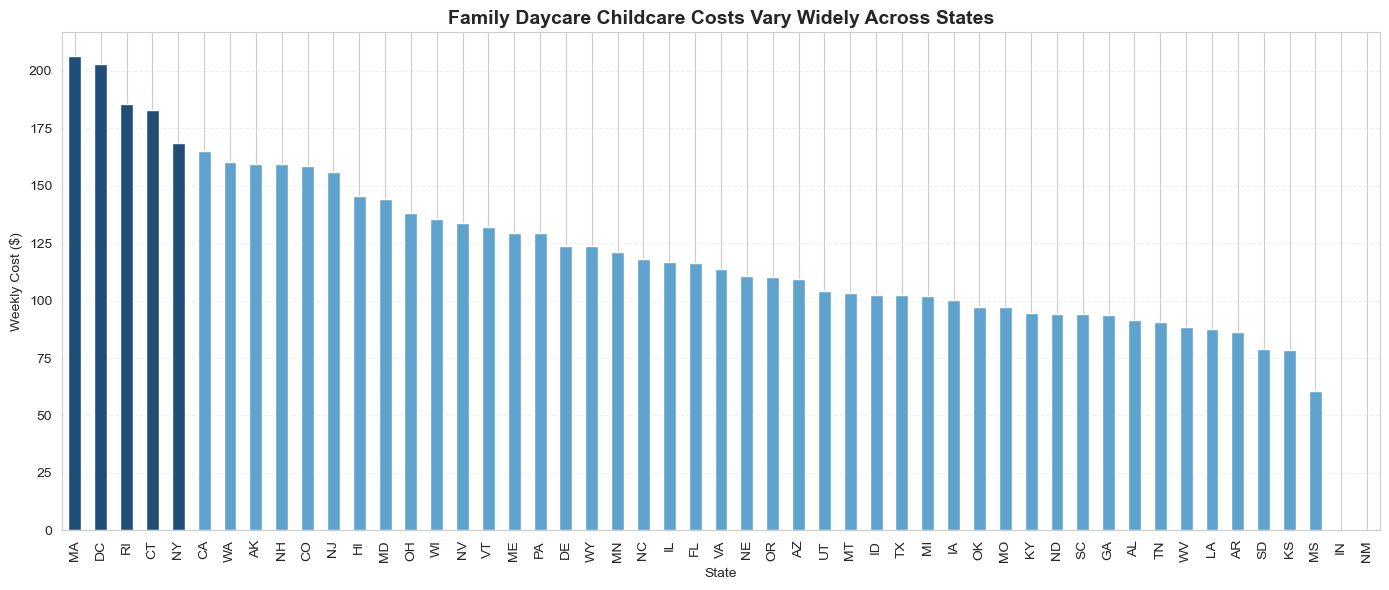

In [6]:
# Step 6
# Average cost by state (family daycare)
# import matplotlib.pyplot as plt

# Average cost by state (family daycare)
state_center = df.groupby("State_Abbreviation")[["MFCCInfant", "MFCCToddler", "MFCCPreschool"]].mean()

# Calculate average across age groups
state_center["Avg_Cost"] = state_center.mean(axis=1, skipna=True)

# Sort highest to lowest
state_center_sorted = state_center.sort_values(by="Avg_Cost", ascending=False)

# Identify top 5 states
top_5_states = state_center_sorted.head(5).index

# Create color list
colors = [
    "#1f4e79" if state in top_5_states else "#5fa2ce"
    for state in state_center_sorted.index
]

# Plot
plt.figure(figsize=(14,6))
state_center_sorted["Avg_Cost"].plot(
    kind="bar",
    color=colors
)

# state_center["Avg_Cost"] = state_center.mean(axis=1, skipna=True)

# Titles and labels (dashboard-ready)
plt.title("Family Daycare Childcare Costs Vary Widely Across States", fontsize=14, fontweight='bold')
plt.ylabel("Weekly Cost ($)")
plt.xlabel("State")
plt.xticks(rotation=90)

# Optional: clean look
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

The bar chart shows clear variation in childcare costs across states, with a small group of states standing out as significantly more expensive than the rest.

-----------------------------------------------------------------------------------------------------------------
Step 7: This code selects the top 10 highest-cost states based on average childcare cost and re-sorts them for a horizontal bar chart. It then plots side-by-side bars for infant, toddler, preschool, and overall average costs using a consistent color scheme to clearly distinguish each category.

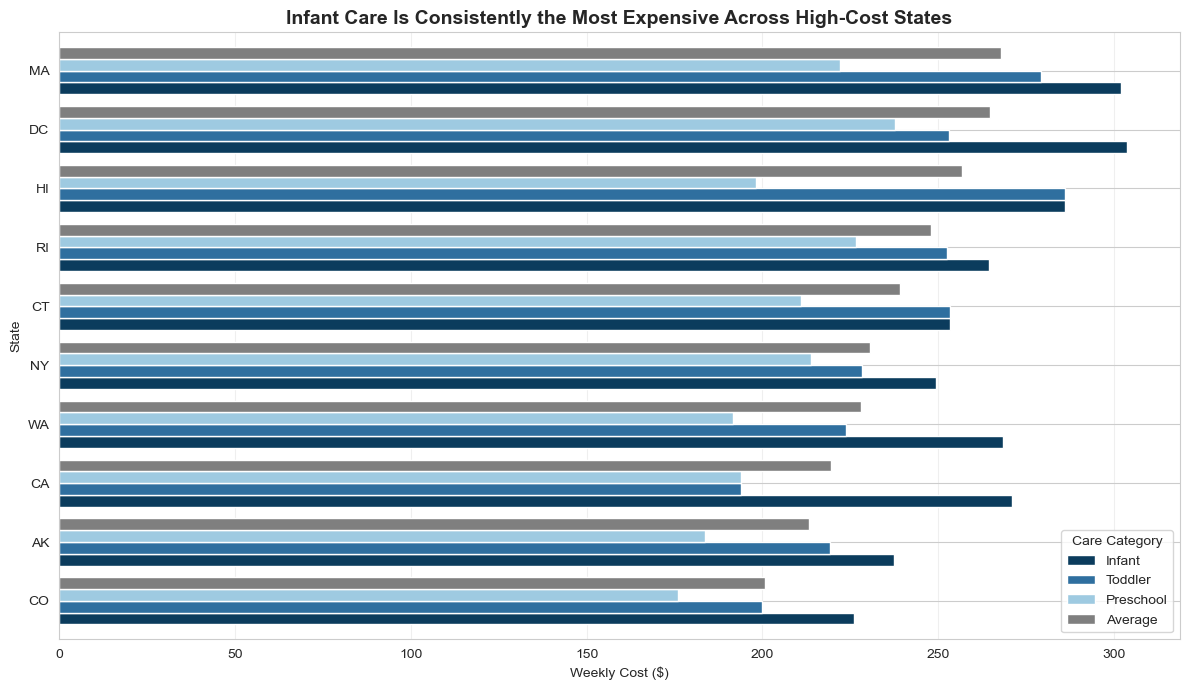

In [7]:
# Step 7
# Average center-based cost by state

state_center_based = df.groupby("State_Abbreviation")[
    ["MCInfant", "MCToddler", "MCPreschool"]
].mean()

# Calculate average across age groups
state_center_based["Avg_Cost"] = state_center_based.mean(axis=1, skipna=True)

# Select top 10 highest-cost states
top_10_plot = (
    state_center_based
    .sort_values(by="Avg_Cost", ascending=False)
    .head(10)
    .sort_values(by="Avg_Cost", ascending=True)
)

colors = {
    "MCInfant": "#0b3c5d",
    "MCToddler": "#2f6f9f",
    "MCPreschool": "#9ecae1",
    "Avg_Cost": "#7f7f7f"
}

top_10_plot[["MCInfant", "MCToddler", "MCPreschool", "Avg_Cost"]].plot(
    kind="barh",
    color=[
        colors["MCInfant"],
        colors["MCToddler"],
        colors["MCPreschool"],
        colors["Avg_Cost"]
    ],
    figsize=(12, 7),
    width=0.8
)

plt.title(
    "Infant Care Is Consistently the Most Expensive Across High-Cost States",
    fontweight="bold",
    fontsize=14
)

plt.xlabel("Weekly Cost ($)")
plt.ylabel("State")
plt.grid(axis="x", alpha=0.3)

plt.legend(
    title="Care Category",
    labels=["Infant", "Toddler", "Preschool", "Average"],
    loc="lower right"
)

plt.tight_layout()
plt.show()

The chart shows that infant care is consistently the most expensive across the highest-cost states, with clear cost differences across age groups but a consistent pricing pattern.  

-----------------------------------------------------------------------------------------------------------------
Step 8: Calculate the overall average weekly childcare cost for family daycare and center-based care, then visualize the difference using a horizontal line with two points representing each care type.

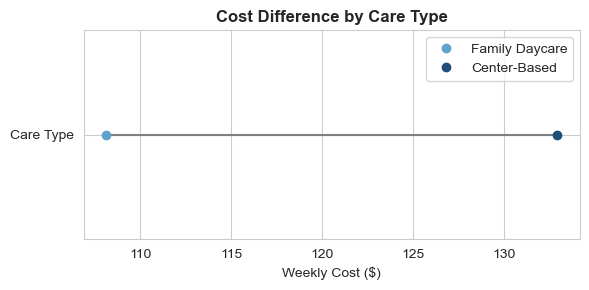

In [8]:
# Step 8a - horizontal line chart

labels = ["Care Type"]
family = df[["MFCCInfant","MFCCToddler","MFCCPreschool"]].mean().mean()
center = df[["MCInfant","MCToddler","MCPreschool"]].mean().mean()

plt.figure(figsize=(6,3))

plt.hlines(y=labels, xmin=family, xmax=center, color="gray")
plt.plot(family, labels, "o", label="Family Daycare", color="#5fa2ce")
plt.plot(center, labels, "o", label="Center-Based", color="#1f4e79")

plt.title("Cost Difference by Care Type", fontweight='bold')
plt.xlabel("Weekly Cost ($)")

plt.legend()
plt.tight_layout()
plt.show()

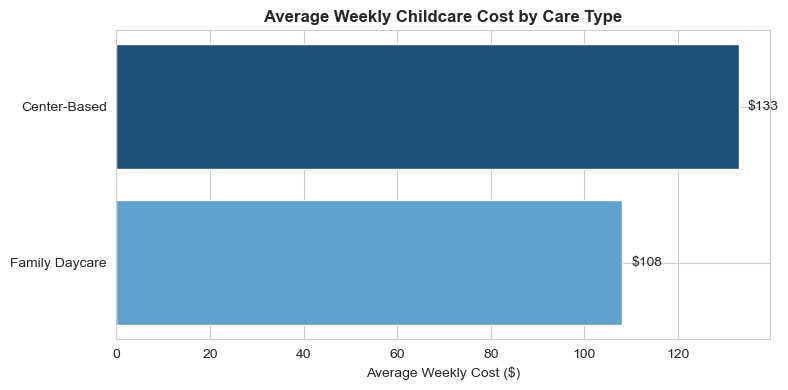

In [9]:
# Step 8b - Horizontal Bar Chart

avg_costs = pd.DataFrame({
    "Care Type": ["Family Daycare", "Center-Based"],
    "Average Weekly Cost": [family, center]
})

plt.figure(figsize=(8,4))

colors = ["#5fa2ce", "#1f4e79"]

plt.barh(
    avg_costs["Care Type"],
    avg_costs["Average Weekly Cost"],
    color=colors
)

# Add value labels to bars
for i, v in enumerate(avg_costs["Average Weekly Cost"]):
    plt.text(v + 2, i, f"${v:.0f}", va='center')

plt.title("Average Weekly Childcare Cost by Care Type", fontweight='bold')
plt.xlabel("Average Weekly Cost ($)")
plt.ylabel("")

plt.tight_layout()
plt.show()

The chart highlights the cost gap between care types, showing that center-based childcare is more expensive than family daycare.  

-----------------------------------------------------------------------------------------------------------------
Step 9: Calculate the average weekly cost of center-based childcare for infants, toddlers, and preschoolers, then visualize the results using a bar chart. Infant care is highlighted with a darker color to emphasize its higher cost relative to the other age groups.

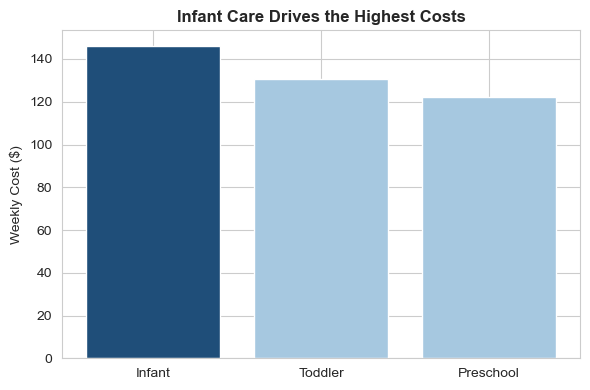

In [10]:
# Step 9
# Calculate averages
age_costs = {
    "Infant": df["MCInfant"].mean(),
    "Toddler": df["MCToddler"].mean(),
    "Preschool": df["MCPreschool"].mean()
}

# Colors: highlight infant
colors = ["#1f4e79", "#a6c8e0", "#a6c8e0"]

plt.figure(figsize=(6,4))
plt.bar(age_costs.keys(), age_costs.values(), color=colors)

plt.title("Infant Care Drives the Highest Costs", fontweight='bold')
plt.ylabel("Weekly Cost ($)")

plt.tight_layout()
plt.show()

The chart shows that infant care is the most expensive, clearly driving overall childcare costs compared to toddler and preschool care.  

-----------------------------------------------------------------------------------------------------------------
Step 10: Calculate the average weekly cost of infant care and compare it to the combined average cost of toddler and preschool care. Create a bar chart to visualize the difference, with infant care highlighted to emphasize its higher cost.

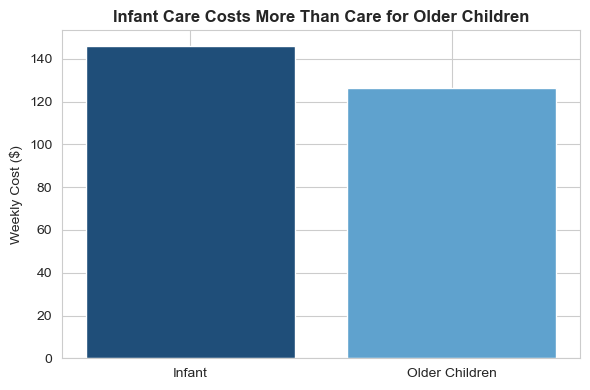

In [11]:
# Step 10
# Calculate averages
infant = df["MCInfant"].mean()
older_children = df[["MCToddler", "MCPreschool"]].mean().mean()

labels = ["Older Children", "Infant"]
values = [older_children, infant]

labels = ["Infant", "Older Children"]
values = [infant, older_children]

colors = ["#1f4e79", "#5fa2ce"]  # highlight infant

plt.figure(figsize=(6,4))
plt.bar(labels, values, color=colors)

plt.title("Infant Care Costs More Than Care for Older Children", fontweight='bold')
plt.ylabel("Weekly Cost ($)")

plt.tight_layout()
plt.show()

The chart clearly shows that infant care is more expensive than care for older children, reinforcing it as the primary cost driver.

-----------------------------------------------------------------------------------------------------------------
Step 11: Calculates the percentage difference between infant care costs and the cost of care for older children, printing result in a formatted output.

In [12]:
# Step 11
percent_diff = ((infant - older_children) / older_children) * 100
print(f"{percent_diff:.1f}% higher")

15.6% higher


Calculates how much higher infant care costs are compared to older children (as a percentage).

-----------------------------------------------------------------------------------------------------------------
Step 12: Calculate the average weekly cost of center-based childcare for infants, toddlers, and preschoolers.  Visualize the results using a bar chart by age group.

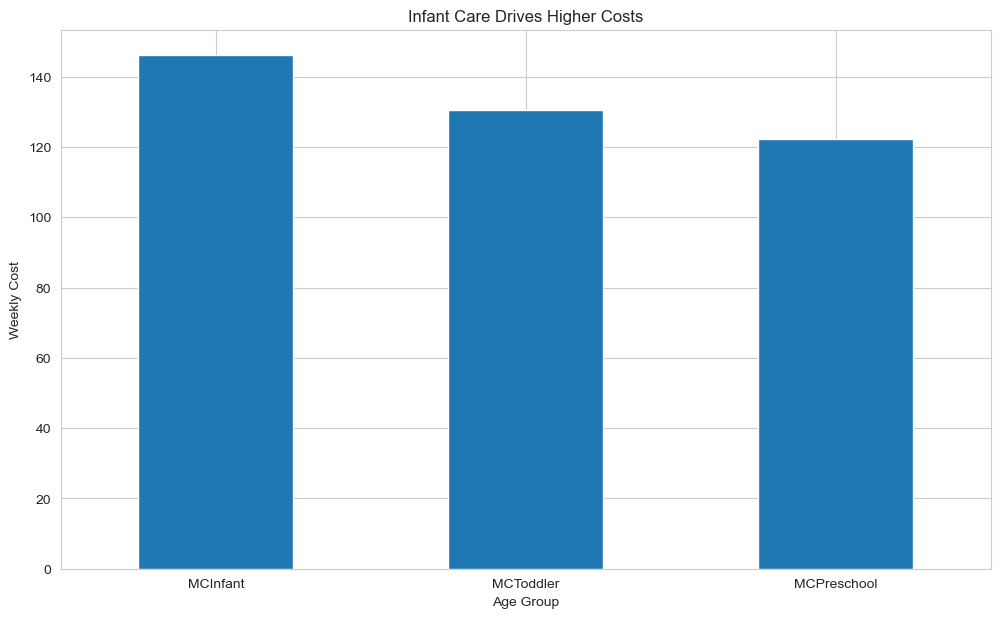

In [13]:
# Step 12
# Average center-based cost by age group
center_age = df[["MCInfant", "MCToddler", "MCPreschool"]].mean()

center_age.plot(kind="bar")

plt.title("Infant Care Drives Higher Costs")
plt.ylabel("Weekly Cost")
plt.xlabel("Age Group")
plt.xticks(rotation=0)
plt.show()

The chart shows that infant care is the most expensive, driving higher overall childcare costs compared to other age groups.

-----------------------------------------------------------------------------------------------------------------
Step 13: Calculate the average weekly cost of family daycare for infants, toddlers, and preschoolers, then visualize the results using a bar chart by age group.

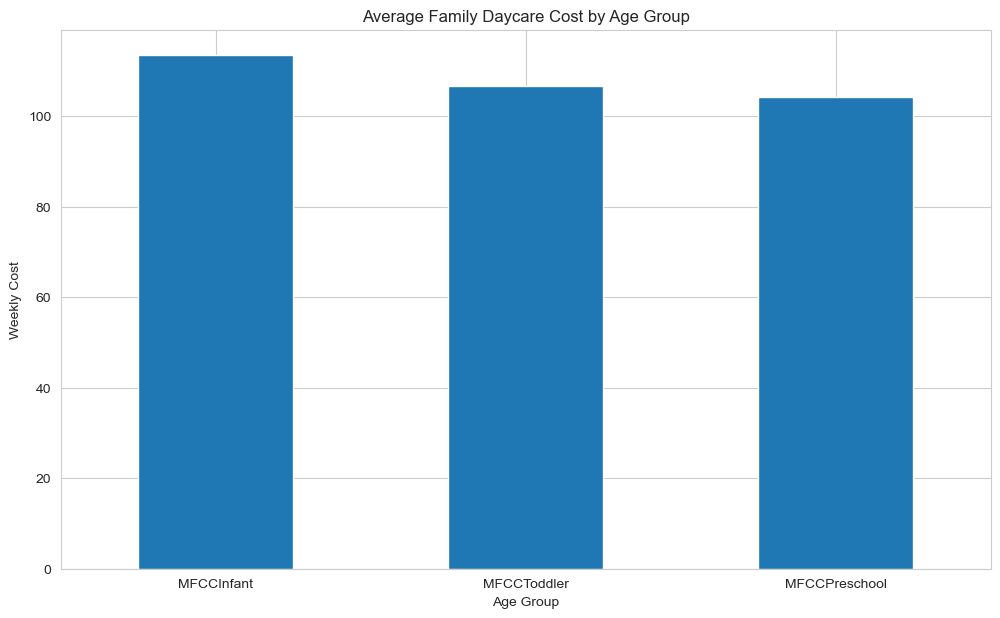

In [14]:
# Step 13
# Average family daycare cost by age group
family_age = df[["MFCCInfant", "MFCCToddler", "MFCCPreschool"]].mean()

family_age.plot(kind="bar")

plt.title("Average Family Daycare Cost by Age Group")
plt.ylabel("Weekly Cost")
plt.xlabel("Age Group")
plt.xticks(rotation=0)
plt.show()

The chart shows how family daycare costs vary by age group, with infant care typically being the highest.

-----------------------------------------------------------------------------------------------------------------
Step 14: Calculates the overall average weekly cost for center-based care and family daycare, organize the results into a DataFrame, and visualize the comparison using a bar chart.

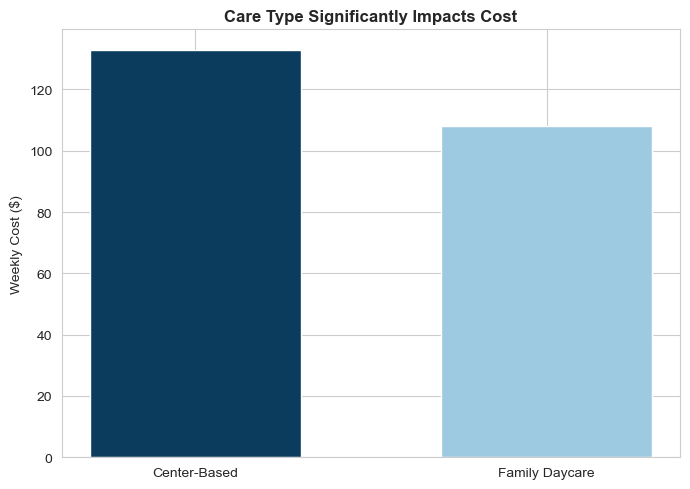

In [16]:
# Step 14
# Average cost by childcare type

center_based = df[["MCInfant", "MCToddler", "MCPreschool"]].mean().mean()

family_daycare = df[
    ["MFCCInfant", "MFCCPreschool", "MFCCToddler"]
].mean().mean()

labels = ["Center-Based", "Family Daycare"]
values = [center_based, family_daycare]

colors = ["#0b3c5d", "#9ecae1"]   # dark blue, light blue

plt.figure(figsize=(7,5))

plt.bar(
    labels,
    values,
    color=colors,
    width=0.6
)

plt.title(
    "Care Type Significantly Impacts Cost",
    fontweight="bold"
)

plt.ylabel("Weekly Cost ($)")
plt.xlabel("")

plt.tight_layout()
plt.show()

The chart shows that care type significantly impacts cost, with center-based childcare being more expensive than family daycare.

-----------------------------------------------------------------------------------------------------------------
Step 15: Define a mapping of U.S. states into regions (Northeast, Midwest, South, West), then apply a function to assign each state in the dataset to its corresponding region, creating a new “Region” column.

In [17]:
# Step 15
region_map = {
    "Northeast": ["NY","NJ","PA","MA","CT","RI","VT","NH","ME"],
    "Midwest": ["IL","IN","MI","OH","WI","MN","IA","MO","ND","SD","NE","KS"],
    "South": ["TX","FL","GA","NC","VA","AL","SC","LA","KY","TN","MS","AR","WV","OK","MD","DE","DC"],
    "West": ["CA","WA","OR","AZ","CO","UT","NV","NM","ID","MT","WY","AK","HI"]
}

def get_region(State_Abbreviation):
    for region, states in region_map.items():
        if State_Abbreviation in states:
            return region
    return "Other"

df["Region"] = df["State_Abbreviation"].apply(get_region)

Established regions by state to perfrom a regional breakdown analysis - grouping states into regions to enable regional analysis of childcare costs.

-----------------------------------------------------------------------------------------------------------------
Step 16: Group the data by region, calculate the average family daycare cost for each age group, and compute an overall average cost per region. Then visualize these averages using a bar chart.

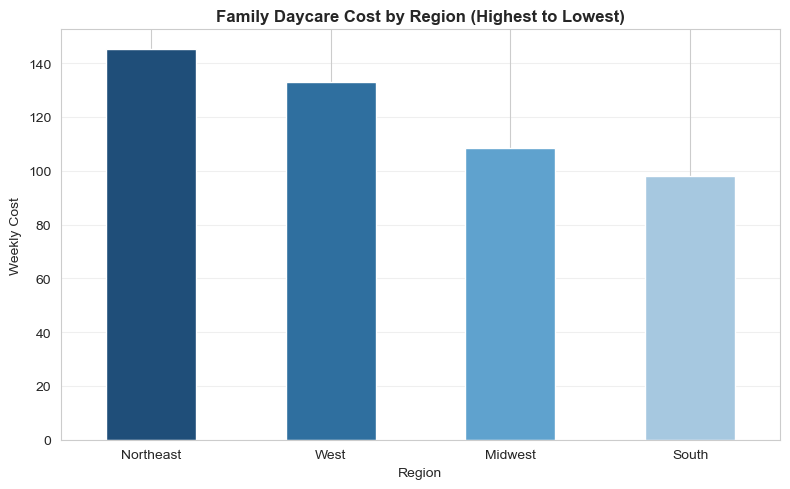

In [18]:
# Step 16
# Group and calculate averages
region_family = df.groupby("Region")[["MFCCInfant","MFCCToddler","MFCCPreschool"]].mean()
region_family["Avg_Cost"] = region_family.mean(axis=1)

# Sort from most to least expensive
region_family_sorted = region_family.sort_values(by="Avg_Cost", ascending=False)

# Create a consistent color gradient (darker = more expensive)
colors = ["#1f4e79", "#2f6f9f", "#5fa2ce", "#a6c8e0"][:len(region_family_sorted)]

# Plot
plt.figure(figsize=(8,5))
region_family_sorted["Avg_Cost"].plot(
    kind="bar",
    color=colors
)

plt.title("Family Daycare Cost by Region (Highest to Lowest)", fontweight='bold')
plt.ylabel("Weekly Cost")
plt.xlabel("Region")
plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The chart shows regional differences in family daycare costs, highlighting which regions are more or less expensive.

-----------------------------------------------------------------------------------------------------------------
Step 17: Summary of Analysis

## Summary of Visual Analysis

- Childcare costs vary significantly across multiple dimensions.
- Costs differ by state, age group, and care type, with infant care and center-based care consistently the most expensive.
- Regional patterns show that some areas experience higher costs than others.
- Overall, childcare affordability is not consistent and depends heavily on location and type of care.

This analysis uses the National Database of Childcare Prices to examine weekly childcare costs across care type, age group, state, and region. The results show clear variation in pricing across the United States, with center-based care generally more expensive than family daycare and infant care consistently driving the highest costs. State and regional comparisons further highlight that affordability challenges are unevenly distributed. Overall, the findings reinforce that childcare affordability is influenced by where families live, the type of care selected, and the age of the child.